In [2]:
import pandas as pd #Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
from google.colab import files #Upload CSV File
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape #Basic EDA
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum() #Check missing values

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
df.rename(columns={ #Rename columns
    "Annual Income (k$)": "Income",
    "Spending Score (1-100)": "Score"
}, inplace=True)

In [8]:
X = df[["Age", "Income", "Score"]] #Select Features for Clustering

In [9]:
scaler = StandardScaler() #Feature Scaling
X_scaled = scaler.fit_transform(X)

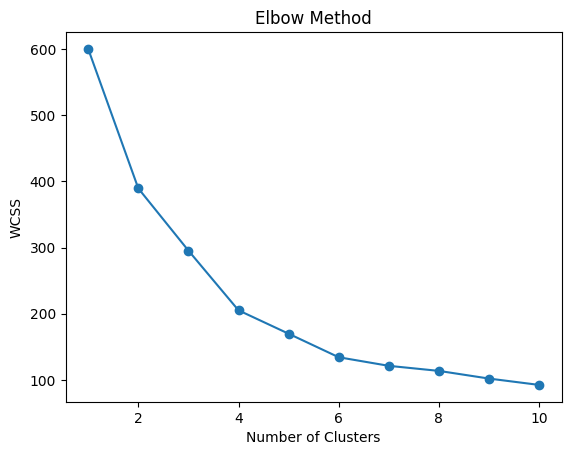

In [10]:
wcss = [] #Find Optimal K

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42) #Apply K-Means Clustering
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [12]:
pca = PCA(n_components=2) #PCA for Visualization
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

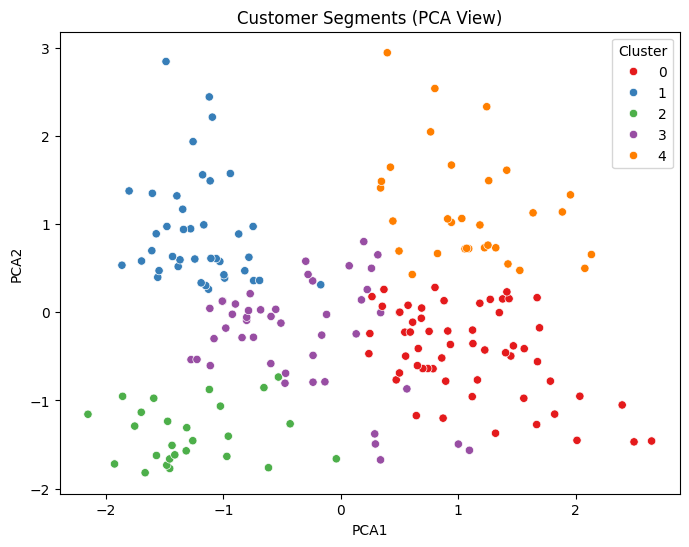

In [13]:
plt.figure(figsize=(8,6)) #Visualize Clusters
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set1")
plt.title("Customer Segments (PCA View)")
plt.show()

In [14]:
df.groupby("Cluster")[["Age", "Income", "Score"]].mean() #Cluster Analysis

,Age,Income,Score
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


In [ ]:
#------------------MARKETING STRATEGY------------------

#🔵 Cluster 0: High Income, High Spending . Target: Premium customers
#Strategy: Luxury offers, VIP memberships,Exclusive deals

#🟢 Cluster 1: Low Income, High Spending. Target: Budget-conscious but impulsive buyers
#Strategy: Discounts, Cashback offers, Bundle deals

#🟡 Cluster 2: High Income, Low Spending. Target: Potential premium customers
#Strategy:Personalized marketing, Premium product recommendations, Loyalty programs

#🔴 Cluster 3: Low Income, Low Spending . Target: Low-value customers
#Strategy: Basic promotions, Cost-effective marketing only, Avoid heavy spending on ads

#🟣 Cluster 4: Middle Income, Medium Spending. Target: Stable customers
#Strategy: Seasonal offers, Product upgrades, Engagement campaigns